In [68]:
# features = [
#     'moisture_active1', 'moisture_active2', 'oxygen', 'co2',
#     'temperature_curing1', 'temperature_curing2',
#     'moisture_curing1', 'moisture_curing2',
#     'methane', 'temperature_active1', 'temperature_active2',
#     'temperature_active3', 'temperature_active4'
# ]

In [69]:
import json

import numpy as np
import pandas as pd

from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

# sequence length (timesteps) and forecast horizon (t+H)
LOOKBACK = 14 # use the past 14 timesteps
HORIZON = 1 # predict next-step by default

# toggle staggered starts
STAGGER_DAYS = 7

PATH = "ideal_inflated_data_oversampled.csv"

In [70]:
df = pd.read_csv(PATH)

In [71]:
df.head()

,Day,temperature_active1,temperature_active2,temperature_active3,temperature_active4,temperature_curing1,temperature_curing2,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2,oxygen,co2,methane,run_id,timestamp
0,-0.358527,35.092597,36.819226,34.785395,36.431947,31.776772,32.523817,57.350263,60.288153,45.107591,45.412658,0.207738,0.005593,0.003254,1,2025-01-01
1,0.092901,34.895281,36.914279,34.091551,35.096042,31.508439,32.579007,57.894716,59.792528,44.767127,45.014193,0.209510,0.004397,0.001792,6,2025-01-01
2,0.507081,34.851548,36.347112,34.846168,35.197103,31.512502,32.823633,57.827417,60.218437,44.974694,45.741831,0.208663,0.003164,0.002102,13,2025-01-01
3,-0.034998,35.282145,36.647914,34.760121,35.888959,31.588972,32.627273,57.680849,59.816770,45.189348,45.621062,0.210904,0.002076,0.003611,18,2025-01-01
4,1.051082,37.343676,38.172620,37.096175,37.956170,31.234828,32.474761,56.888628,58.877555,44.687204,45.833656,0.195277,0.021704,0.003760,1,2025-01-02


In [72]:
# define column mapping

mapping = {
    "A_temps": ["temperature_active1", "temperature_active2"],
    "B_temps": ["temperature_active3", "temperature_active4"],
    "curing_temps": ["temperature_curing1", "temperature_curing2"],
    "o2": "oxygen",
    "co2": "co2",
    "ch4": "methane",
    "moisture_cols": ["moisture_active1", "moisture_active2", "moisture_curing1", "moisture_curing2"],
    "time_col": "timestamp",
}

for k in ["A_temps", "B_temps", "curing_temps", "moisture_cols"]:
    mapping[k] = [c for c in mapping.get(k, []) if c in df.columns]

for gas_key in ["o2", "co2", "ch4"]:
    if mapping[gas_key] not in df.columns:
        mapping[gas_key] = None

time_col = mapping["time_col"] if mapping["time_col"] in df.columns else None

print("Column mapping: ")
print(json.dumps(mapping, indent=2))

Column mapping: 
{
  "A_temps": [
    "temperature_active1",
    "temperature_active2"
  ],
  "B_temps": [
    "temperature_active3",
    "temperature_active4"
  ],
  "curing_temps": [
    "temperature_curing1",
    "temperature_curing2"
  ],
  "o2": "oxygen",
  "co2": "co2",
  "ch4": "methane",
  "moisture_cols": [
    "moisture_active1",
    "moisture_active2",
    "moisture_curing1",
    "moisture_curing2"
  ],
  "time_col": "timestamp"
}


In [73]:
# CELL 4 — Feature engineering (A/B features + staggered starts) — PATCHED

# Ensure timestamp is datetime and sorted
time_col = mapping["time_col"] if mapping["time_col"] in df.columns else None
if time_col:
    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df = df.sort_values(time_col).reset_index(drop=True)

def safe_mean(cols):
    return df[cols].mean(axis=1) if cols else pd.Series(np.nan, index=df.index)

def safe_delta(cols):
    return (df[cols[0]] - df[cols[1]]).abs() if len(cols) >= 2 else pd.Series(np.nan, index=df.index)

A_mean = safe_mean(mapping["A_temps"])
B_mean = safe_mean(mapping["B_temps"])
A_delta = safe_delta(mapping["A_temps"])
B_delta = safe_delta(mapping["B_temps"])
cross_mean_diff = A_mean - B_mean

# Ambient proxy
combo = pd.concat([A_mean, B_mean], axis=1).mean(axis=1)
ambient = combo.rolling(14, min_periods=1).min()

# Stagger parameters
t0 = df[time_col].min() if time_col else pd.Timestamp("2025-01-01")
A_START = t0 + pd.Timedelta(days=int(STAGGER_DAYS))
B_START = t0

# Hours since load and loaded flags
if time_col:
    A_time_h = (df[time_col] - A_START).dt.total_seconds().clip(lower=0)/3600.0
    B_time_h = (df[time_col] - B_START).dt.total_seconds().clip(lower=0)/3600.0
else:
    A_time_h = pd.Series(range(len(df)), index=df.index).astype(float)
    B_time_h = pd.Series(range(len(df)), index=df.index).astype(float)
A_loaded = (A_time_h > 0).astype(int)
B_loaded = (B_time_h > 0).astype(int)

# Only include shared gases if present
feat_parts = {
    "A_mean": A_mean,
    "B_mean": B_mean,
    "A_delta": A_delta,
    "B_delta": B_delta,
    "cross_mean_diff": cross_mean_diff,
    "ambient": ambient,
    "A_time_h": A_time_h,
    "B_time_h": B_time_h,
    "A_loaded": A_loaded,
    "B_loaded": B_loaded,
}
if mapping["o2"] and mapping["o2"] in df.columns:
    feat_parts["oxygen"] = pd.to_numeric(df[mapping["o2"]], errors="coerce")
if mapping["co2"] and mapping["co2"] in df.columns:
    feat_parts["co2"] = pd.to_numeric(df[mapping["co2"]], errors="coerce")
if mapping["ch4"] and mapping["ch4"] in df.columns:
    feat_parts["methane"] = pd.to_numeric(df[mapping["ch4"]], errors="coerce")

feat = pd.DataFrame(feat_parts)

# Optional moisture
moist_list = mapping.get("moisture_cols", [])
for c in moist_list:
    if c in df.columns:
        feat[c] = pd.to_numeric(df[c], errors="coerce")

# 🔑 Drop features that are entirely NaN (e.g., missing gases)
feat = feat.dropna(axis=1, how="all")

# 🔑 Light imputation for the remaining features (keeps time order)
feat = feat.interpolate(limit_direction="both").ffill().bfill()

# Targets = next-step temps for each probe
targets = {}
for i, c in enumerate(mapping["A_temps"]):
    targets[f"A_{i+1}_next"] = pd.to_numeric(df[c], errors="coerce").shift(-HORIZON)
for i, c in enumerate(mapping["B_temps"]):
    targets[f"B_{i+1}_next"] = pd.to_numeric(df[c], errors="coerce").shift(-HORIZON)
y_df = pd.DataFrame(targets)

display(feat.head(5))
display(y_df.head(5))
print("Feature columns used:", list(feat.columns))


,A_mean,B_mean,A_delta,B_delta,cross_mean_diff,ambient,A_time_h,B_time_h,A_loaded,B_loaded,oxygen,co2,methane,moisture_active1,moisture_active2,moisture_curing1,moisture_curing2
0,35.955911,35.608671,1.726629,1.646551,0.347240,35.782291,0.0,0.0,0,0,0.207738,0.005593,0.003254,57.350263,60.288153,45.107591,45.412658
1,35.904780,34.593797,2.018998,1.004491,1.310984,35.249289,0.0,0.0,0,0,0.209510,0.004397,0.001792,57.894716,59.792528,44.767127,45.014193
2,35.599330,35.021635,1.495564,0.350936,0.577695,35.249289,0.0,0.0,0,0,0.208663,0.003164,0.002102,57.827417,60.218437,44.974694,45.741831
3,35.965029,35.324540,1.365768,1.128838,0.640489,35.249289,0.0,0.0,0,0,0.210904,0.002076,0.003611,57.680849,59.816770,45.189348,45.621062
4,37.758148,37.526173,0.828944,0.859995,0.231976,35.249289,0.0,24.0,0,1,0.195277,0.021704,0.003760,56.888628,58.877555,44.687204,45.833656


,A_1_next,A_2_next,B_1_next,B_2_next
0,34.895281,36.914279,34.091551,35.096042
1,34.851548,36.347112,34.846168,35.197103
2,35.282145,36.647914,34.760121,35.888959
3,37.343676,38.172620,37.096175,37.956170
4,35.508596,36.256182,34.673288,36.222054


Feature columns used: ['A_mean', 'B_mean', 'A_delta', 'B_delta', 'cross_mean_diff', 'ambient', 'A_time_h', 'B_time_h', 'A_loaded', 'B_loaded', 'oxygen', 'co2', 'methane', 'moisture_active1', 'moisture_active2', 'moisture_curing1', 'moisture_curing2']


In [74]:
# CELL 5 — Build sliding-window sequences — PATCHED

feature_cols = list(feat.columns)
target_cols_A = [c for c in y_df.columns if c.startswith("A_")]
target_cols_B = [c for c in y_df.columns if c.startswith("B_")]

# Valid rows: require targets present (features were imputed above)
valid_idx = y_df[target_cols_A + target_cols_B].notnull().all(axis=1)
feat_v = feat[valid_idx].reset_index(drop=True)
y_v = y_df[valid_idx].reset_index(drop=True)

# Loaded flags at aligned (valid) rows
A_loaded_v = feat_v["A_loaded"].astype(int).values
B_loaded_v = feat_v["B_loaded"].astype(int).values

# Build sequences
X_list, yA_list, yB_list = [], [], []
A_sw_list, B_sw_list = [], []

F = len(feature_cols)
for end in range(LOOKBACK, len(feat_v)):
    start = end - LOOKBACK
    X_win = feat_v.iloc[start:end][feature_cols].values  # (LOOKBACK, F)

    # Targets at 'end' index (already shifted by HORIZON)
    yA = y_v.iloc[end][target_cols_A].values if target_cols_A else np.array([])
    yB = y_v.iloc[end][target_cols_B].values if target_cols_B else np.array([])

    # Sample weights per head at target time
    sw_A = float(A_loaded_v[end]) if len(yA) else 0.0
    sw_B = float(B_loaded_v[end]) if len(yB) else 0.0

    X_list.append(X_win)
    yA_list.append(yA)
    yB_list.append(yB)
    A_sw_list.append(sw_A)
    B_sw_list.append(sw_B)

X = np.array(X_list)                                   # (N, LOOKBACK, F)
yA = np.array(yA_list) if target_cols_A else None
yB = np.array(yB_list) if target_cols_B else None
A_sw = np.array(A_sw_list, dtype="float32")
B_sw = np.array(B_sw_list, dtype="float32")

print("X shape:", X.shape)
if yA is not None: print("yA shape:", yA.shape, "| A_sw shape:", A_sw.shape)
if yB is not None: print("yB shape:", yB.shape, "| B_sw shape:", B_sw.shape)

# Safety check for small datasets
if X.shape[0] == 0:
    raise ValueError(
        "No training windows were created. Try reducing LOOKBACK (e.g., LOOKBACK = 5) "
        "or verify that your target columns have non-NaN values."
    )

# Keep a frame of target-time metadata for evaluation
meta_t = feat_v.iloc[LOOKBACK:].reset_index(drop=True)[["A_loaded","B_loaded"]]


X shape: (505, 14, 17)
yA shape: (505, 2) | A_sw shape: (505,)
yB shape: (505, 2) | B_sw shape: (505,)


In [75]:
# Scale targets (important for LSTM training)

y_scaler_A, y_scaler_B = None, None

if yA is not None and yA.shape[1] > 0:
    y_scaler_A = StandardScaler()
    yA = y_scaler_A.fit_transform(yA)
    print("Scaled A targets. Mean:", y_scaler_A.mean_, "Std:", y_scaler_A.scale_)

if yB is not None and yB.shape[1] > 0:
    y_scaler_B = StandardScaler()
    yB = y_scaler_B.fit_transform(yB)
    print("Scaled B targets. Mean:", y_scaler_B.mean_, "Std:", y_scaler_B.scale_)


Scaled A targets. Mean: [42.72522523 43.32266642] Std: [7.09139503 7.05417707]
Scaled B targets. Mean: [41.83998083 43.02364432] Std: [7.10153637 7.09338722]


In [76]:
# CELL 6 — Blocked train/test split + scaling

from sklearn.preprocessing import StandardScaler

N = X.shape[0]
cut = int(N * 0.8)  # 80/20 time split
idx_tr = np.arange(cut)
idx_te = np.arange(cut, N)

X_tr, X_te = X[idx_tr], X[idx_te]
A_tr, A_te = (yA[idx_tr] if yA is not None else None), (yA[idx_te] if yA is not None else None)
B_tr, B_te = (yB[idx_tr] if yB is not None else None), (yB[idx_te] if yB is not None else None)
A_sw_tr, A_sw_te = A_sw[idx_tr], A_sw[idx_te]
B_sw_tr, B_sw_te = B_sw[idx_tr], B_sw[idx_te]

# Standardize features (fit on train only)
scaler = StandardScaler()
X_tr_2d = X_tr.reshape(-1, X_tr.shape[-1])
X_te_2d = X_te.reshape(-1, X_te.shape[-1])

scaler.fit(X_tr_2d)
X_tr_scaled = scaler.transform(X_tr_2d).reshape(X_tr.shape)
X_te_scaled = scaler.transform(X_te_2d).reshape(X_te.shape)

print("Train windows:", X_tr.shape[0], " Test windows:", X_te.shape[0])


Train windows: 404  Test windows: 101


In [77]:
# CELL 7 — Build the shared LSTM encoder with two heads (A/B)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

n_features = X_tr.shape[-1]
out_A = A_tr.shape[-1] if A_tr is not None else 0
out_B = B_tr.shape[-1] if B_tr is not None else 0

inputs = keras.Input(shape=(LOOKBACK, n_features))
x = layers.Masking(mask_value=0.0)(inputs)
x = layers.LSTM(32, return_sequences=True)(x)
x = layers.Dropout(0.1)(x)
x = layers.LSTM(32)(x)
x = layers.Dropout(0.1)(x)

head_A = layers.Dense(16, activation="relu")(x) if out_A else None
outA  = layers.Dense(out_A, name="outA")(head_A) if out_A else None

head_B = layers.Dense(16, activation="relu")(x) if out_B else None
outB  = layers.Dense(out_B, name="outB")(head_B) if out_B else None

# --- PATCH: use integer flags, not KerasTensors, for conditionals ---
outputs = []
losses = {}
metrics = {}

if out_A > 0:
    outputs.append(outA)
    losses["outA"] = "mae"
    metrics["outA"] = ["mae"]

if out_B > 0:
    outputs.append(outB)
    losses["outB"] = "mae"
    metrics["outB"] = ["mae"]

if not outputs:
    raise ValueError("No outputs defined. Check your mapping/targets and that out_A/out_B > 0.")

model = keras.Model(inputs, outputs, name="LIDA_TwoHead_LSTM")
model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=losses, metrics=metrics)
model.summary()



Model: "LIDA_TwoHead_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 14, 17)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal_6         │ (None, 14, 17)    │          0 │ input_layer_6[0]… │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking_6 (Masking) │ (None, 14, 17)    │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any_6 (Any)         │ (None, 14)        │          0 │ not_equal_6[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_12 (LSTM)      │ (None, 14, 32)    │      6,400 │ masking_6[0][0],  │
│                     │                   │            │ any_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 14, 32)    │          0 │ lstm_12[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_13 (LSTM)      │ (None, 32)        │      8,320 │ dropout_12[0][0], │
│                     │                   │            │ any_6[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 32)        │          0 │ lstm_13[0][0]     │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │        528 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 16)        │        528 │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outA (Dense)        │ (None, 2)         │         34 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outB (Dense)        │ (None, 2)         │         34 │ dense_13[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 15,844 (61.89 KB)

 Trainable params: 15,844 (61.89 KB)

 Non-trainable params: 0 (0.00 B)

In [78]:
# --- PATCH: build target and weight dicts using out_A/out_B integers ---
y_tr, y_te = {}, {}
sw_tr, sw_te = {}, {}

if out_A > 0:
    y_tr["outA"] = A_tr
    y_te["outA"] = A_te
    sw_tr["outA"] = A_sw_tr
    sw_te["outA"] = A_sw_te

if out_B > 0:
    y_tr["outB"] = B_tr
    y_te["outB"] = B_te
    sw_tr["outB"] = B_sw_tr
    sw_te["outB"] = B_sw_te


In [79]:
# --- PATCH: unpack predictions based on number of model outputs and out_A/out_B ---
preds = model.predict(X_te_scaled, verbose=0)

predA, predB = None, None
if len(model.outputs) == 2:
    predA, predB = preds  # order matches outputs list (outA then outB)
elif len(model.outputs) == 1:
    if out_A > 0:
        predA = preds
    elif out_B > 0:
        predB = preds
else:
    raise RuntimeError("Unexpected number of outputs from model.")

mae = {}
if out_A > 0 and predA is not None:
    mae["A_total"] = float(mean_absolute_error(A_te.flatten(), predA.flatten()))
if out_B > 0 and predB is not None:
    mae["B_total"] = float(mean_absolute_error(B_te.flatten(), predB.flatten()))


In [80]:
# Inverse-transform predictions back to °C for interpretability
if out_A > 0 and predA is not None and y_scaler_A is not None:
    predA = y_scaler_A.inverse_transform(predA)
    A_te = y_scaler_A.inverse_transform(A_te)

if out_B > 0 and predB is not None and y_scaler_B is not None:
    predB = y_scaler_B.inverse_transform(predB)
    B_te = y_scaler_B.inverse_transform(B_te)


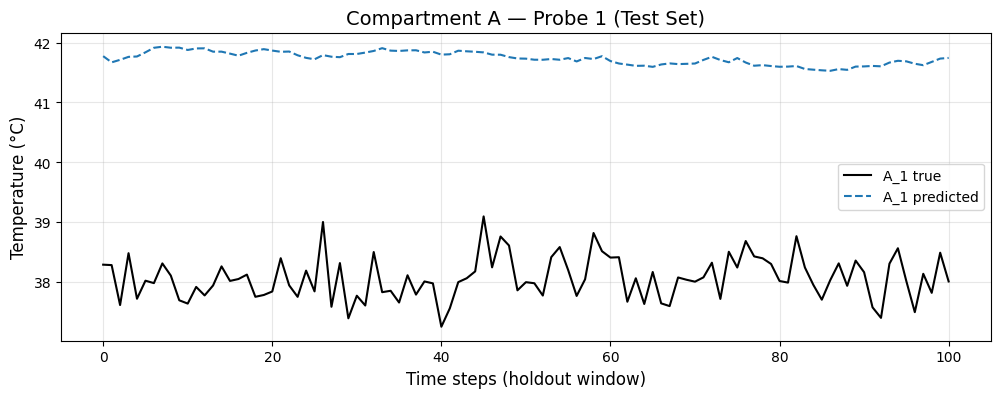

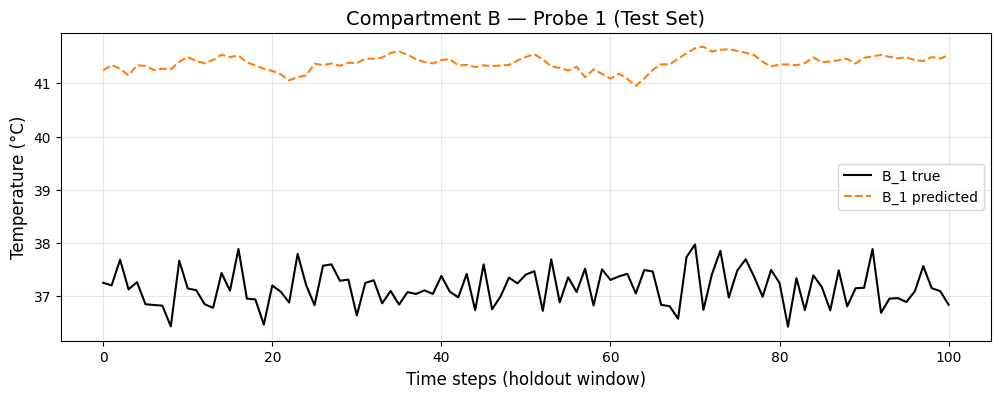

In [81]:
import matplotlib.pyplot as plt

# Plot A probe 1
if out_A > 0 and A_tr.shape[1] >= 1 and predA is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(A_te[:,0], label="A_1 true", color="black")
    plt.plot(predA[:,0], label="A_1 predicted", linestyle="--", color="tab:blue")
    plt.title("Compartment A — Probe 1 (Test Set)", fontsize=14)
    plt.xlabel("Time steps (holdout window)", fontsize=12)
    plt.ylabel("Temperature (°C)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Plot B probe 1
if out_B > 0 and B_tr.shape[1] >= 1 and predB is not None:
    plt.figure(figsize=(12, 4))
    plt.plot(B_te[:,0], label="B_1 true", color="black")
    plt.plot(predB[:,0], label="B_1 predicted", linestyle="--", color="tab:orange")
    plt.title("Compartment B — Probe 1 (Test Set)", fontsize=14)
    plt.xlabel("Time steps (holdout window)", fontsize=12)
    plt.ylabel("Temperature (°C)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
